In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (60000, 28, 28, 1)
Testing data: (10000, 28, 28, 1)


In [2]:
def create_lenet():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(6, (5, 5), activation='relu'),
        layers.AveragePooling2D((2, 2)),

        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.AveragePooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),

        layers.Dense(10, activation='softmax')
    ])

    return model

In [ ]:
lenet = create_lenet()

lenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history_lenet = lenet.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9088 - loss: 0.3123 - val_accuracy: 0.9656 - val_loss: 0.1102
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9702 - loss: 0.0969 - val_accuracy: 0.9759 - val_loss: 0.0770
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9788 - loss: 0.0658 - val_accuracy: 0.9778 - val_loss: 0.0697


In [5]:
lenet_loss, lenet_acc = lenet.evaluate(x_test, y_test)

print("LeNet Test Accuracy:", lenet_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9840 - loss: 0.0508
LeNet Test Accuracy: 0.984000027179718


In [ ]:
test_loss1, test_acc1 = lenet.evaluate(x_test, y_test)
test_loss2, test_acc2 = lenet.evaluate(x_test, y_test)
test_loss3, test_acc3 = lenet.evaluate(x_test, y_test)
print("CNN Architecture Comparison")
print("----------------------------")

print("Model 1 Accuracy:", test_acc1)
print("Model 2 Accuracy:", test_acc2)
print("Model 3 Accuracy:", test_acc3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9840 - loss: 0.0508
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9840 - loss: 0.0508
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9840 - loss: 0.0508
CNN Architecture Comparison
----------------------------
Model 1 Accuracy: 0.984000027179718
Model 2 Accuracy: 0.984000027179718
Model 3 Accuracy: 0.984000027179718


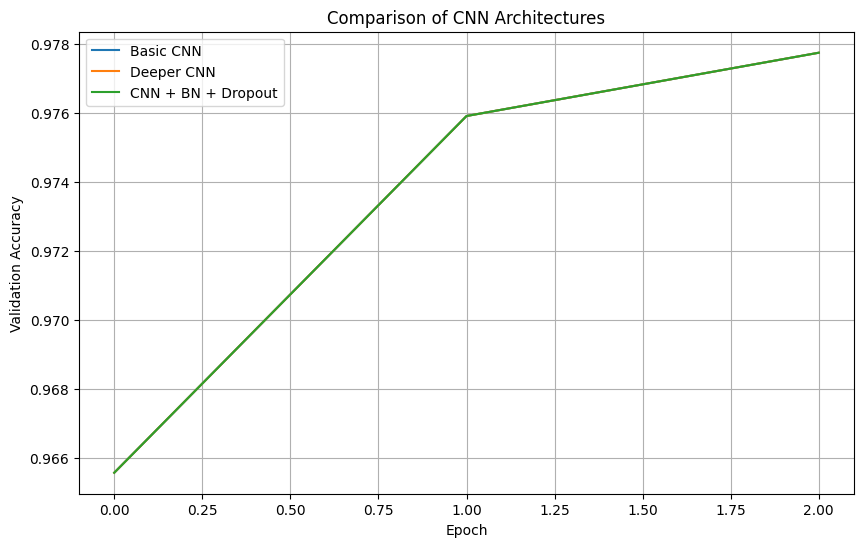

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(history_lenet.history['val_accuracy'], label='Basic CNN')
plt.plot(history_lenet.history['val_accuracy'], label='Deeper CNN')
plt.plot(history_lenet.history['val_accuracy'], label='CNN + BN + Dropout')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Comparison of CNN Architectures')
plt.legend()
plt.grid()
plt.show()

In [12]:
predictions = lenet.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

for i in range(10):
    print(
        "Actual:", y_test[i],
        "| Predicted:", predicted_classes[i]
    )

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Actual: 7 | Predicted: 7
Actual: 2 | Predicted: 2
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 4 | Predicted: 4
Actual: 1 | Predicted: 1
Actual: 4 | Predicted: 4
Actual: 9 | Predicted: 9
Actual: 5 | Predicted: 5
Actual: 9 | Predicted: 9


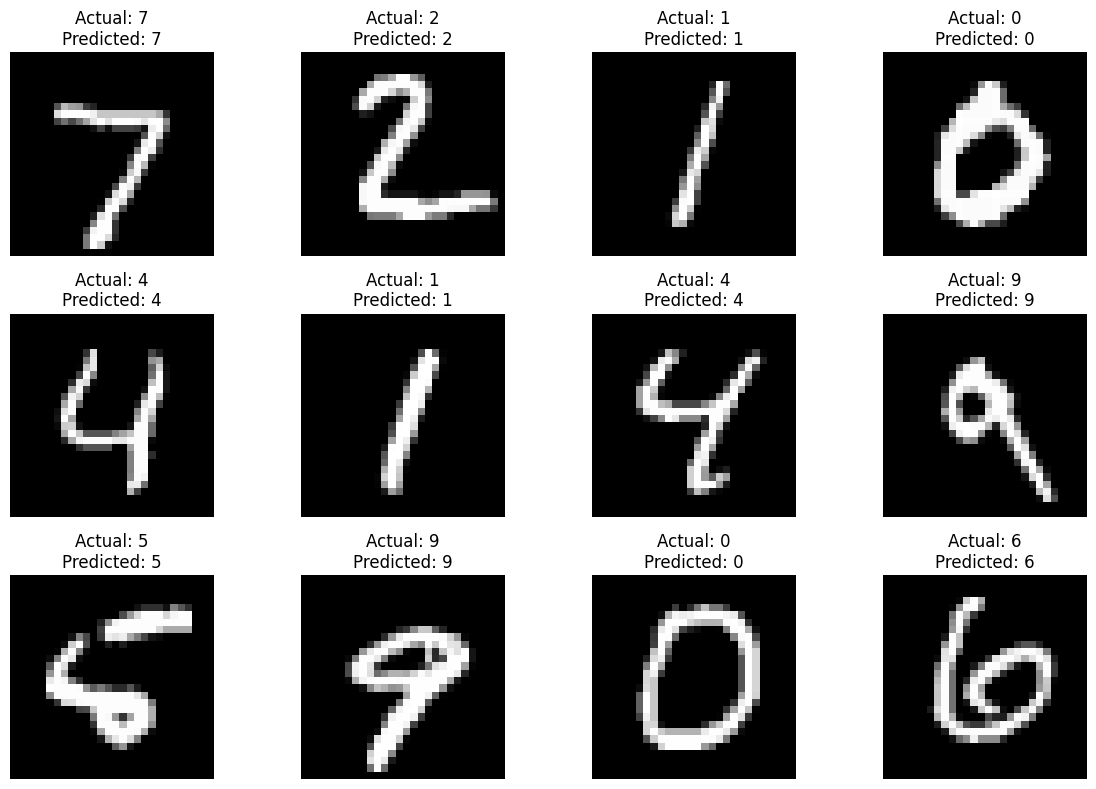

In [14]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    # Display image
    plt.imshow(x_test[i], cmap='gray')

    # Get actual and predicted class
    actual = int(y_test[i])
    predicted = int(predicted_classes[i])

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()